In [108]:

import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from qcm.data.band import BandDataset
import matplotlib.pyplot as plt


In [42]:
train_dataset = BandDataset(image_size=16, num_samples=1000, num_channels=1)
valid_dataset = BandDataset(image_size=16, num_samples=200, num_channels=1)

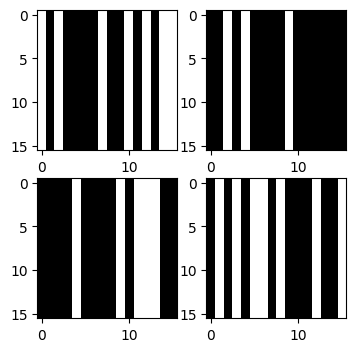

In [43]:
imgs = [train_dataset[idx][0] for idx in range(4)]
fig, axs = plt.subplots(2, 2, figsize=(4, 4))
for i in range(2):
    for j in range(2):
        axs[i,j].imshow(imgs[i+2*j][0, ...], cmap='gray')
plt.show()

In [44]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [ ]:
import lightning as L 

class HybridModel(L.LightningModule):
    def __init__(self, encoder, reupload, learning_rate=1e-3):
        super().__init__()
        self.encoder = encoder
        self.normalisation = torch.nn.Sigmoid()
        self.reupload = reupload
        self.learning_rate = learning_rate

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x = self.encoder(x)
        x = self.normalisation(x)
        return self.reupload(x, y)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.forward(x, y).mean()
        return loss

    def configure_optimizers(self):
        optimizer = Adam(self.parameters(), lr=self.learning_rate)
        scheduler = CosineAnnealingLR(optimizer, T_max=10)
        return [optimizer], [scheduler]

(<Figure size 1500x400 with 1 Axes>, <Axes: >)


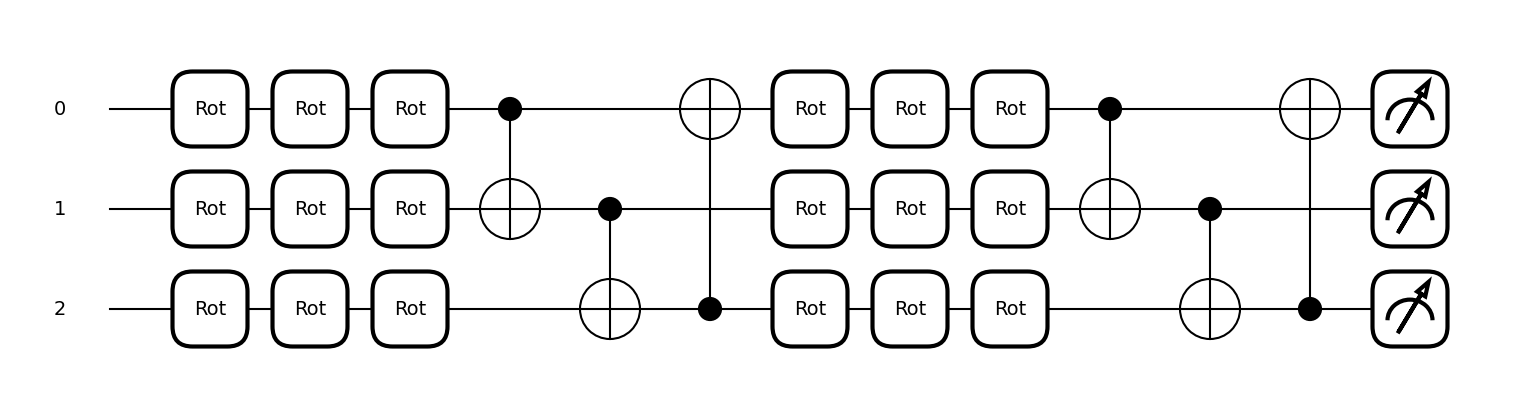

In [104]:
from qcm.components.encoder.band import BandEncoder
from qcm.components.reupload.reupload import QuantumHeadReupload
import pennylane as qml

encoder = BandEncoder(filters = 6, latent_dim = 18)
reupload = QuantumHeadReupload(num_qubits=3, num_features = 18, num_classes=2, n_repetitions=2)
model = HybridModel(encoder, reupload)
model.reupload.draw_circuit()

In [107]:
trainer = L.Trainer(max_epochs=20, accelerator='cpu', devices=1, logger=False)
trainer.fit(model, train_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/renau001/miniconda3/envs/medical_imaging/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/renau001/miniconda3/envs/medical_imaging/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/renau001/projects/quantum/QML-Medicine/docs/notebooks/checkpoints exists and is not empty.

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | encoder       | BandEncoder         | 1.6 K  | train
1 | normalisation | Sigmoid             | 0      | tr

Epoch 19: 100%|██████████| 32/32 [00:00<00:00, 59.79it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 32/32 [00:00<00:00, 59.39it/s]
